In [2]:
import tensorflow as tf

print("Versión de TensorFlow:", tf.__version__)

# Buscamos las placas de video disponibles
gpus = tf.config.list_physical_devices('GPU')

print("Cantidad de GPUs detectadas:", len(gpus))

if gpus:
    print("¡ÉXITO! Tu placa de video se encontro correctamente")
    for gpu in gpus:
        print("Detalle:", gpu)
else:
    print(" no se encontro la GPU. Estamos usando  (CPU)")

Versión de TensorFlow: 2.10.0
Cantidad de GPUs detectadas: 1
¡ÉXITO! Tu placa de video se encontro correctamente
Detalle: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

# Descargamos los números escritos a mano
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Normalizamos los píxeles (de 0-255 a 0-1) para que la IA aprenda más rápido
train_images, test_images = train_images / 255.0, test_images / 255.0

print(f"¡Datos cargados! Tenemos {len(train_images)} imágenes para entrenar.")

¡Datos cargados! Tenemos 60000 imágenes para entrenar.


In [4]:
model = models.Sequential([
    # Capa que "mira" la imagen y busca patrones
    layers.Flatten(input_shape=(28, 28)), 
    # Capa densa con 128 neuronas (el motor de pensamiento)
    layers.Dense(128, activation='relu'),
    # Capa de salida: 10 neuronas (una por cada número del 0 al 9)
    layers.Dense(10, activation='softmax')
])

# Configuramos cómo va a aprender
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________


In [5]:
print("Iniciando entrenamiento en la GPU...")
# acá utilizo mi placa de video rtx3060 para el entrenamiento 
model.fit(train_images, train_labels, epochs=5)

Iniciando entrenamiento en la GPU...
Epoch 1/5
1875/1875 [==============================] - 5s 2ms/step - loss: 0.2562 - accuracy: 0.9271
Epoch 2/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.1120 - accuracy: 0.9669
Epoch 3/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0767 - accuracy: 0.9770
Epoch 4/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0580 - accuracy: 0.9816
Epoch 5/5
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0449 - accuracy: 0.9855


In [6]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nPrecisión final del examen: {test_acc*100:.2f}%')

313/313 - 1s - loss: 0.0679 - accuracy: 0.9783 - 771ms/epoch - 2ms/step

Precisión final del examen: 97.83%


In [7]:
# Guardamos el modelo en formato HDF5.
model.save('modelo_numeros.h5')
print("¡Modelo guardado como 'modelo_numeros.h5'")

¡Modelo guardado como 'modelo_numeros.h5'


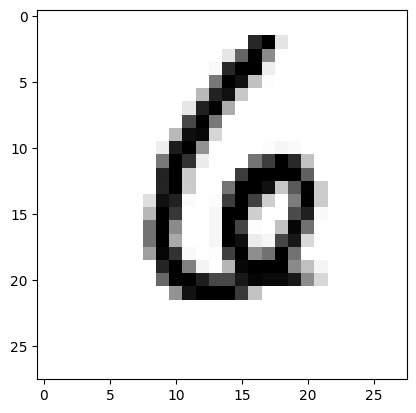

1/1 [==============================] - 0s 69ms/step
 número es un: 6


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Elegí un número de imagen al azar (de 0 a 9999)
indice = 123 

# Mostramos la imagen
plt.imshow(test_images[indice], cmap=plt.cm.binary)
plt.show()

# Le pedimos a la IA que nos diga qué es
prediccion = model.predict(test_images[indice:indice+1])
numero_predicho = np.argmax(prediccion)

print(f" número es un: {numero_predicho}")